<a href="https://colab.research.google.com/github/duduvieiras/tech-challenge-fase-1/blob/main/Tech%20Challenge%20-%20Top_5%20Produtos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

pd.read_csv("/content/olist_customers_dataset.csv")
pd.read_csv("/content/olist_geolocation_dataset.csv")
pd.read_csv("/content/olist_order_items_dataset.csv")
pd.read_csv("/content/olist_order_payments_dataset.csv")
pd.read_csv("/content/olist_order_reviews_dataset.csv")
pd.read_csv("/content/olist_orders_dataset.csv")
pd.read_csv("/content/olist_products_dataset.csv")
pd.read_csv("/content/olist_sellers_dataset.csv")

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [ ]:
customers_df = pd.read_csv("/content/olist_customers_dataset.csv")
geolocation_df = pd.read_csv("/content/olist_geolocation_dataset.csv")
order_items_df = pd.read_csv("/content/olist_order_items_dataset.csv")
order_payments_df = pd.read_csv("/content/olist_order_payments_dataset.csv")
order_reviews_df = pd.read_csv("/content/olist_order_reviews_dataset.csv")
orders_df = pd.read_csv("/content/olist_orders_dataset.csv")
products_df = pd.read_csv("/content/olist_products_dataset.csv")
sellers_df = pd.read_csv("/content/olist_sellers_dataset.csv")

print("Colunas do DataFrame de Clientes:", customers_df.columns.tolist())
print("Colunas do DataFrame de Geolocalização:", geolocation_df.columns.tolist())
print("Colunas do DataFrame de Itens do Pedido:", order_items_df.columns.tolist())
print("Colunas do DataFrame de Pagamentos de Pedidos:", order_payments_df.columns.tolist())
print("Colunas do DataFrame de Avaliações de Pedidos:", order_reviews_df.columns.tolist())
print("Colunas do DataFrame de Pedidos:", orders_df.columns.tolist())
print("Colunas do DataFrame de Produtos:", products_df.columns.tolist())
print("Colunas do DataFrame de Vendedores:", sellers_df.columns.tolist())

Colunas do DataFrame de Clientes: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
Colunas do DataFrame de Geolocalização: ['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
Colunas do DataFrame de Itens do Pedido: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Colunas do DataFrame de Pagamentos de Pedidos: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
Colunas do DataFrame de Avaliações de Pedidos: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
Colunas do DataFrame de Pedidos: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Colunas do Dat

In [ ]:
orders_customers_df = pd.merge(orders_df, customers_df, on='customer_id', how='left')
order_items_products_df = pd.merge(order_items_df, products_df, on='product_id', how='left')
order_items_products_sellers_df = pd.merge(order_items_products_df, sellers_df, on='seller_id', how='left')

# Mescla dos dados principais de pedidos, clientes, itens, produtos e vendedores.
merged_df = pd.merge(orders_customers_df, order_items_products_sellers_df, on='order_id', how='left')

# Mescla de dados de pagamento
merged_df = pd.merge(merged_df, order_payments_df, on='order_id', how='left')

# Mescla de dados de avaliação
merged_df = pd.merge(merged_df, order_reviews_df, on='order_id', how='left')

# Exibir as primeiras linhas e colunas do DataFrame final mesclado.
print("Formato do DataFrame final mesclado:", merged_df.shape)
print("Colunas do DataFrame final mesclado:", merged_df.columns.tolist())
merged_df.head()

Formato do DataFrame final mesclado: (119143, 39)
Colunas do DataFrame final mesclado: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [ ]:
# Converter a coluna 'order_purchase_timestamp' para o tipo datetime.

merged_df['order_purchase_timestamp'] = pd.to_datetime(merged_df['order_purchase_timestamp'])
merged_df['ano'] = merged_df['order_purchase_timestamp'].dt.year

In [ ]:
# Extrair o ano dessa coluna.
# Filtrar os dados para os anos desejados
# Agrupar os dados por ano e product_category_name para contar as vendas.
# Selecionar os 5 produtos mais vendidos para cada ano.

years_to_process = [2016, 2017, 2018]
top_produtos_por_ano = {}

for year in years_to_process:
    df_year = merged_df[merged_df['ano'] == year].copy() # Usar .copy() para evitar SettingWithCopyWarning

    # Agrupe por 'nome_da_categoria_do_produto' e conte as vendas, depois reinicie o índice.
    product_sales_count = df_year.groupby('product_category_name').size().reset_index(name='sales_count')

    # Calcule o valor total de vendas para cada categoria
    product_sales_value = df_year.groupby('product_category_name')['payment_value'].sum().reset_index(name='total_sales_value')

    # Mesclar as contagens de vendas e os valores de vendas
    product_sales_combined = pd.merge(product_sales_count, product_sales_value, on='product_category_name', how='left')

    # Classifique e obtenha os 5 melhores produtos.
    top_5_produtos = product_sales_combined.sort_values(by='sales_count', ascending=False).head(5)
    top_produtos_por_ano[year] = top_5_produtos

# Exibir os 5 melhores produtos de cada ano.
for year, df in top_produtos_por_ano.items():
    print(f"\nTop 5 produtos mais vendidos em {year}:")
    display(df)


Top 5 produtos mais vendidos em 2016:


,product_category_name,sales_count,total_sales_value
23,moveis_decoracao,81,11563.88
4,beleza_saude,53,6062.16
25,perfumaria,36,7201.84
5,brinquedos,27,5670.74
19,informatica_acessorios,24,2396.70



Top 5 produtos mais vendidos em 2017:


,product_category_name,sales_count,total_sales_value
13,cama_mesa_banho,5774,822686.86
54,moveis_decoracao,4439,683997.68
32,esporte_lazer,4308,648160.04
11,beleza_saude,3846,621563.82
44,informatica_acessorios,3242,709654.08



Top 5 produtos mais vendidos em 2018:


,product_category_name,sales_count,total_sales_value
13,cama_mesa_banho,6206,919020.23
11,beleza_saude,6133,1035337.61
44,informatica_acessorios,4884,887430.28
32,esporte_lazer,4677,748135.92
54,moveis_decoracao,4312,748402.05


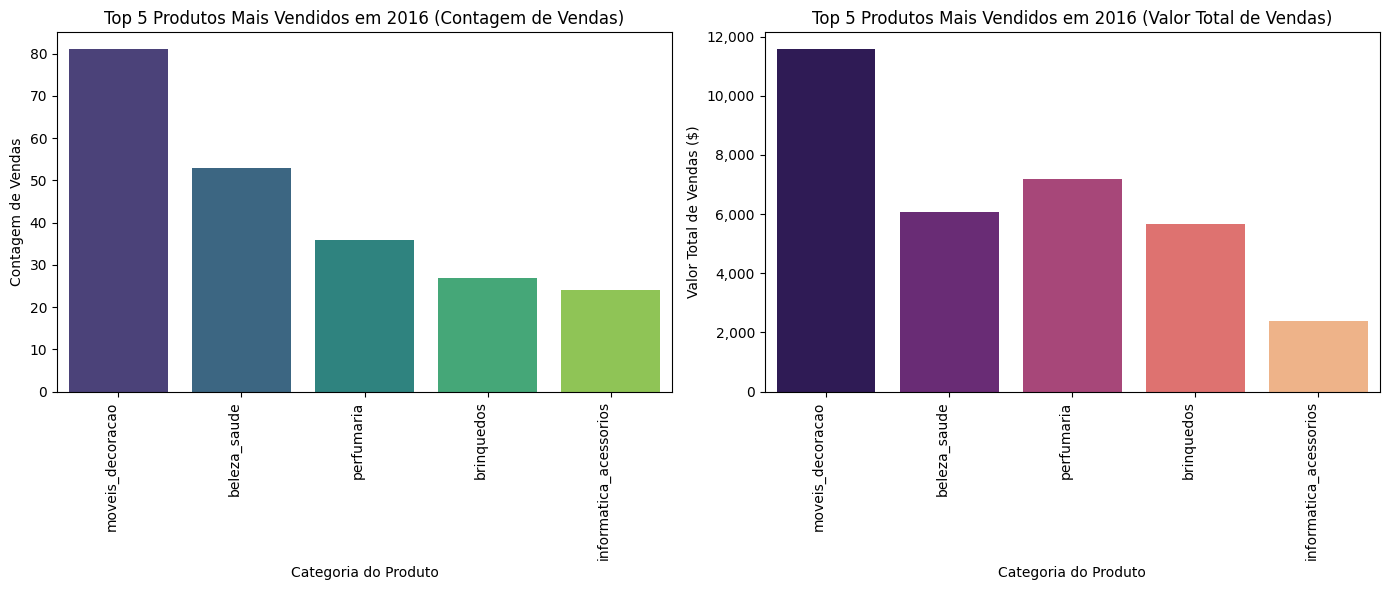

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

df_2016 = top_produtos_por_ano[2016]

plt.figure(figsize=(14, 6))

# Subplot para Contagem de Vendas
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
sns.barplot(x='product_category_name', y='sales_count', data=df_2016, hue='product_category_name', palette='viridis', legend=False)
plt.title('Top 5 Produtos Mais Vendidos em 2016 (Contagem de Vendas)')
plt.xlabel('Categoria do Produto')
plt.ylabel('Contagem de Vendas')
plt.xticks(rotation=90, ha='right')

# Subplot para Valor Total de Vendas
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
sns.barplot(x='product_category_name', y='total_sales_value', data=df_2016, hue='product_category_name', palette='magma', legend=False)
plt.title('Top 5 Produtos Mais Vendidos em 2016 (Valor Total de Vendas)')
plt.xlabel('Categoria do Produto')
plt.ylabel('Valor Total de Vendas ($)')
plt.xticks(rotation=90, ha='right')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # Adiciona separador de milhares

plt.tight_layout()
plt.show()

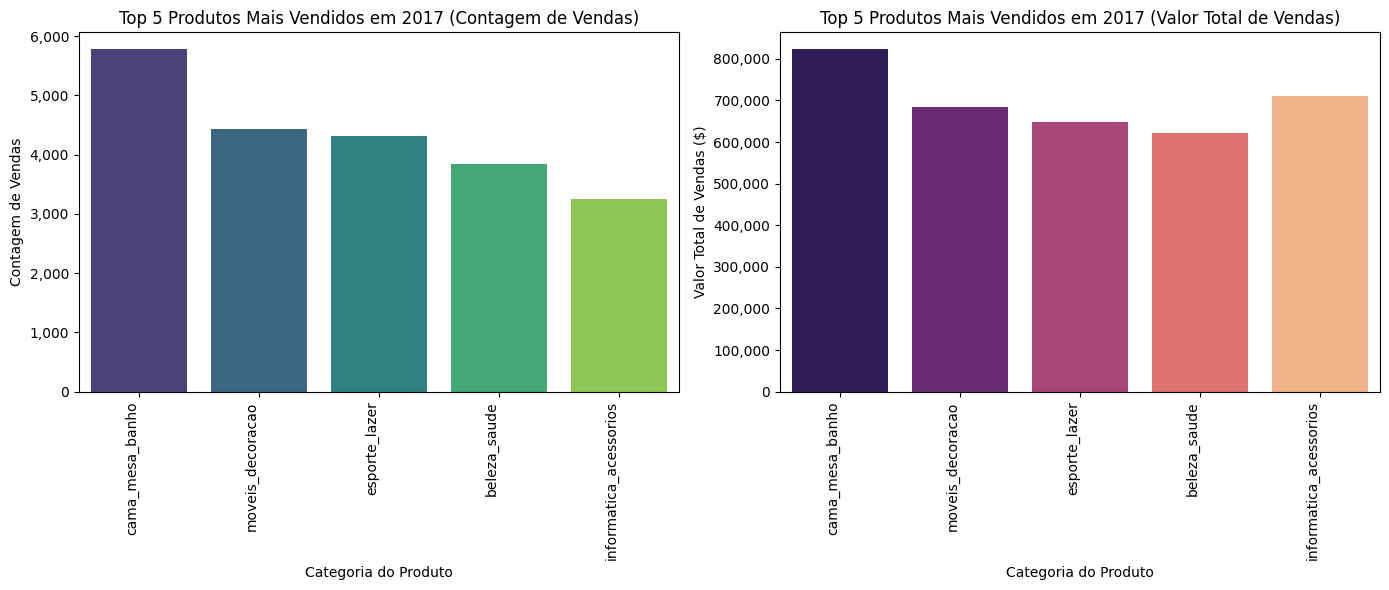

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

df_2017 = top_produtos_por_ano[2017]

plt.figure(figsize=(14, 6))

# Subplot para Contagem de Vendas
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
sns.barplot(x='product_category_name', y='sales_count', data=df_2017, hue='product_category_name', palette='viridis', legend=False)
plt.title('Top 5 Produtos Mais Vendidos em 2017 (Contagem de Vendas)')
plt.xlabel('Categoria do Produto')
plt.ylabel('Contagem de Vendas')
plt.xticks(rotation=90, ha='right')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # Adiciona separador de milhares

# Subplot para Valor Total de Vendas
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
sns.barplot(x='product_category_name', y='total_sales_value', data=df_2017, hue='product_category_name', palette='magma', legend=False)
plt.title('Top 5 Produtos Mais Vendidos em 2017 (Valor Total de Vendas)')
plt.xlabel('Categoria do Produto')
plt.ylabel('Valor Total de Vendas ($)')
plt.xticks(rotation=90, ha='right')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # Adiciona separador de milhares

plt.tight_layout()
plt.show()

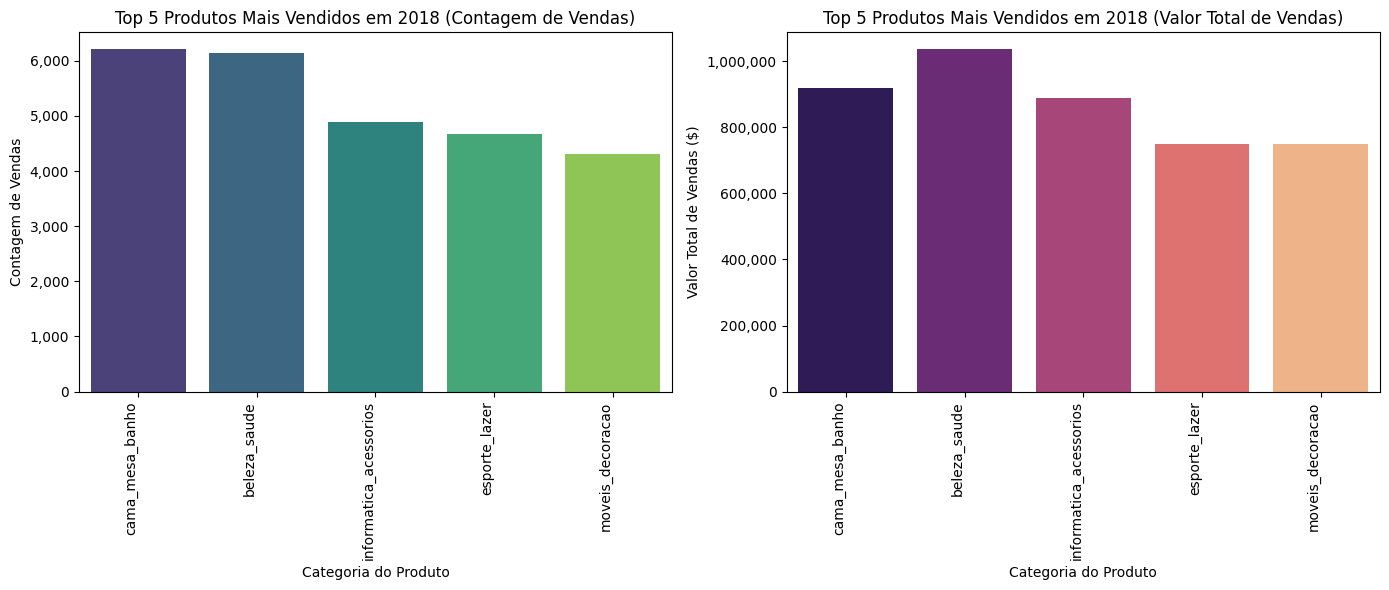

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

df_2018 = top_produtos_por_ano[2018]

plt.figure(figsize=(14, 6))

# Subplot para Contagem de Vendas
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, 1º gráfico
sns.barplot(x='product_category_name', y='sales_count', data=df_2018, hue='product_category_name', palette='viridis', legend=False)
plt.title('Top 5 Produtos Mais Vendidos em 2018 (Contagem de Vendas)')
plt.xlabel('Categoria do Produto')
plt.ylabel('Contagem de Vendas')
plt.xticks(rotation=90, ha='right')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # Adiciona separador de milhares

# Subplot para Valor Total de Vendas
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, 2º gráfico
sns.barplot(x='product_category_name', y='total_sales_value', data=df_2018, hue='product_category_name', palette='magma', legend=False)
plt.title('Top 5 Produtos Mais Vendidos em 2018 (Valor Total de Vendas)')
plt.xlabel('Categoria do Produto')
plt.ylabel('Valor Total de Vendas ($)')
plt.xticks(rotation=90, ha='right')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # Adiciona separador de milhares

plt.tight_layout()
plt.show()